# Part G: Classification Algorithms from Scratch

In this notebook, we implement key classification algorithms from scratch using NumPy:
1. **Linear Discriminant Analysis (LDA)**
2. **Binary Logistic Regression**
3. **Multinomial Logistic Regression (Softmax)**
4. **Naive Bayes Classifier (Gaussian)**
5. **Support Vector Machine (SVM) with Hinge Loss and RBF Kernel**

We will evaluate these models using synthetic datasets generated using NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)

## 1. Linear Discriminant Analysis (LDA) from Scratch

LDA projects features into a lower-dimensional space that maximizes class separability. It maximizes the ratio of between-class variance ($S_B$) to within-class variance ($S_W$).
$$\text{Objective: } J(w) = \frac{w^T S_B w}{w^T S_W w}$$

In [2]:
class LDAFromScratch:
    def fit(self, X, y):
        n_features = X.shape[1]
        class_labels = np.unique(y)
        
        # Overall mean
        mean_overall = np.mean(X, axis=0)
        
        S_W = np.zeros((n_features, n_features))
        S_B = np.zeros((n_features, n_features))
        
        for c in class_labels:
            X_c = X[y == c]
            mean_c = np.mean(X_c, axis=0)
            
            # Within-class scatter matrix
            S_W += (X_c - mean_c).T @ (X_c - mean_c)
            
            # Between-class scatter matrix
            n_c = X_c.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(-1, 1)
            S_B += n_c * (mean_diff @ mean_diff.T)
            
        # Solve the generalized eigenvalue problem: S_W^-1 S_B w = lambda w
        # Regularize S_W to ensure invertibility
        S_W += 1e-6 * np.eye(n_features)
        eig_vals, eig_vecs = np.linalg.eig(np.linalg.inv(S_W) @ S_B)
        
        # Sort eigenvectors by eigenvalues in descending order
        idx = np.argsort(np.abs(eig_vals))[::-1]
        self.linear_discriminants = eig_vecs[:, idx][:, :1] # Project to 1D
        
    def transform(self, X):
        return X @ self.linear_discriminants

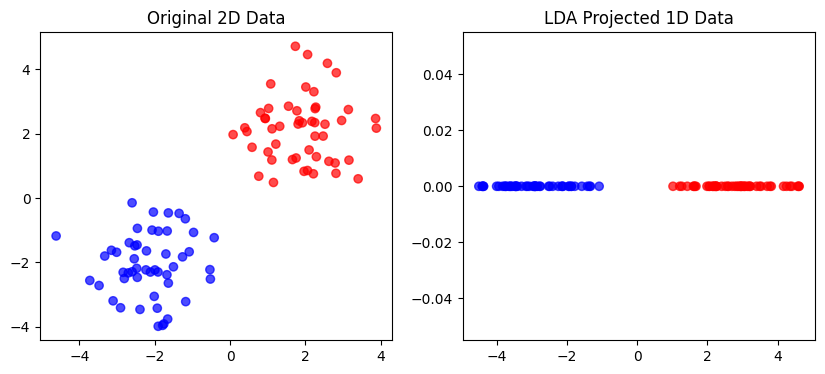

In [3]:
# Generate synthetic 2-class data
X1 = np.random.randn(50, 2) + np.array([-2, -2])
X2 = np.random.randn(50, 2) + np.array([2, 2])
X = np.vstack((X1, X2))
y = np.array([0]*50 + [1]*50)

lda = LDAFromScratch()
lda.fit(X, y)
X_projected = lda.transform(X)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.title('Original 2D Data')
plt.subplot(1, 2, 2)
plt.scatter(X_projected, np.zeros_like(X_projected), c=y, cmap='bwr', alpha=0.7)
plt.title('LDA Projected 1D Data')
plt.show()

## 2. Binary and Multinomial Logistic Regression

Binary Logistic Regression uses the Sigmoid activation function, whereas Multinomial uses the Softmax function for multi-class classification.

In [4]:
class LogisticRegressionFromScratch:
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))
        
    def fit_binary(self, X, y, lr=0.01, epochs=5000):
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        y = y.reshape(-1, 1)
        
        for epoch in range(epochs):
            z = X @ self.theta
            h = self.sigmoid(z)
            gradient = (1 / m) * (X.T @ (h - y))
            self.theta -= lr * gradient
            
    def predict_prob_binary(self, X):
        return self.sigmoid(X @ self.theta)
        
    def predict_binary(self, X):
        return (self.predict_prob_binary(X) >= 0.5).astype(int)
        
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit_multinomial(self, X, y, lr=0.01, epochs=5000):
        m, n = X.shape
        self.classes = np.unique(y)
        k = len(self.classes)
        self.W = np.zeros((n, k))
        
        # One-hot encode y
        y_one_hot = np.zeros((m, k))
        for idx, val in enumerate(y):
            y_one_hot[idx, val] = 1
            
        for epoch in range(epochs):
            z = X @ self.W
            probs = self.softmax(z)
            gradient = (1 / m) * (X.T @ (probs - y_one_hot))
            self.W -= lr * gradient
            
    def predict_multinomial(self, X):
        probs = self.softmax(X @ self.W)
        return np.argmax(probs, axis=1)

In [5]:
# Test Binary Logistic Regression
X_b = np.c_[np.ones(len(X)), X]
model_bin = LogisticRegressionFromScratch()
model_bin.fit_binary(X_b, y)
preds_bin = model_bin.predict_binary(X_b).flatten()
print(f"Binary Logistic Regression Accuracy: {np.mean(preds_bin == y)*100}%")

# Test Multinomial Logistic Regression on 3-class synthetic data
X_m1 = np.random.randn(30, 2) + np.array([-3, -3])
X_m2 = np.random.randn(30, 2) + np.array([0, 3])
X_m3 = np.random.randn(30, 2) + np.array([3, -3])
X_multi = np.vstack((X_m1, X_m2, X_m3))
X_multi_b = np.c_[np.ones(len(X_multi)), X_multi]
y_multi = np.array([0]*30 + [1]*30 + [2]*30)

model_multi = LogisticRegressionFromScratch()
model_multi.fit_multinomial(X_multi_b, y_multi)
preds_multi = model_multi.predict_multinomial(X_multi_b)
print(f"Multinomial Logistic Regression Accuracy: {np.mean(preds_multi == y_multi)*100}%")

Binary Logistic Regression Accuracy: 100.0%
Multinomial Logistic Regression Accuracy: 100.0%


## 3. Naive Bayes Classifier from Scratch

We implement the **Gaussian Naive Bayes** classifier, which assumes features follow a normal distribution within each class.
$$P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

In [6]:
class NaiveBayesFromScratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means = {}
        self.vars = {}
        self.priors = {}
        
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.vars[c] = np.var(X_c, axis=0) + 1e-9 # Prevent divide by zero
            self.priors[c] = X_c.shape[0] / X.shape[0]
            
    def _pdf(self, class_idx, x):
        mean = self.means[class_idx]
        var = self.vars[class_idx]
        numerator = np.exp(- (x - mean)**2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator
        
    def predict(self, X):
        preds = []
        for x in X:
            posteriors = []
            for c in self.classes:
                prior = np.log(self.priors[c])
                conditional = np.sum(np.log(self._pdf(c, x)))
                posterior = prior + conditional
                posteriors.append((posterior, c))
            preds.append(max(posteriors)[1])
        return np.array(preds)

In [7]:
nb = NaiveBayesFromScratch()
nb.fit(X, y)
nb_preds = nb.predict(X)
print(f"Naive Bayes Accuracy: {np.mean(nb_preds == y)*100}%")

Naive Bayes Accuracy: 100.0%


## 4. Support Vector Machine (SVM) from Scratch

We implement a Soft-Margin SVM using subgradient descent with Hinge Loss. We also implement an RBF (Gaussian) kernel.
$$J(w, b) = \frac{1}{2} ||w||^2 + C \sum_{i=1}^{m} \max(0, 1 - y^{(i)}(w^T X^{(i)} + b))$$

In [8]:
class SVMFromScratch:
    def __init__(self, C=1.0, kernel='linear', sigma=1.0):
        self.C = C
        self.kernel_type = kernel
        self.sigma = sigma
        
    def _rbf_kernel(self, X1, X2):
        # Pairwise distance matrix squared
        sq_dists = np.sum(X1**2, 1, keepdims=True) + np.sum(X2**2, 1) - 2 * (X1 @ X2.T)
        return np.exp(-sq_dists / (2 * self.sigma**2))
        
    def fit(self, X, y, lr=0.001, epochs=5000):
        m, n = X.shape
        # Convert targets to -1 and 1
        y_temp = np.where(y <= 0, -1, 1).reshape(-1, 1)
        
        if self.kernel_type == 'linear':
            self.w = np.zeros((n, 1))
            self.b = 0.0
            for epoch in range(epochs):
                for idx, x_i in enumerate(X):
                    condition = y_temp[idx] * (x_i @ self.w + self.b) >= 1
                    if condition:
                        self.w -= lr * (2 * 1/epochs * self.w)
                    else:
                        self.w -= lr * (2 * 1/epochs * self.w - self.C * y_temp[idx] * x_i.reshape(-1, 1))
                        self.b -= lr * (-self.C * y_temp[idx])
        else:
            # Kernelized Dual SVM via Subgradient Ascent/Descent
            self.X_train = X
            self.y_train = y_temp
            self.alpha = np.zeros((m, 1))
            K = self._rbf_kernel(X, X)
            self.b = 0.0
            
            for epoch in range(epochs):
                for idx in range(m):
                    margin = y_temp[idx] * (np.sum(self.alpha * self.y_train * K[:, idx:idx+1]) + self.b)
                    if margin < 1:
                        self.alpha[idx] += lr * (self.C - self.alpha[idx])
                        self.b += lr * self.C * y_temp[idx]
                    else:
                        self.alpha[idx] -= lr * self.alpha[idx]
                        
    def predict(self, X):
        if self.kernel_type == 'linear':
            decision = X @ self.w + self.b
        else:
            K = self._rbf_kernel(X, self.X_train)
            decision = np.sum(self.alpha.T * self.y_train.T * K, axis=1, keepdims=True) + self.b
        return np.where(decision >= 0, 1, 0)

In [9]:
# Test Linear SVM
svm_linear = SVMFromScratch(C=1.0, kernel='linear')
svm_linear.fit(X, y)
svm_preds = svm_linear.predict(X).flatten()
print(f"Linear SVM Accuracy: {np.mean(svm_preds == y)*100}%")

# Test RBF SVM
svm_rbf = SVMFromScratch(C=1.0, kernel='rbf', sigma=1.5)
svm_rbf.fit(X, y)
svm_rbf_preds = svm_rbf.predict(X).flatten()
print(f"RBF SVM Accuracy: {np.mean(svm_rbf_preds == y)*100}%")

Linear SVM Accuracy: 100.0%


RBF SVM Accuracy: 100.0%
